## Part 1: Data Visualization

## Part 1: Data Visualization

We first found the Titanic dataset from Kaggle, linked here: https://www.kaggle.com/competitions/titanic/overview. Seaborn has the titanic dataset built-in, so we decided to use that for convenience. Using the Seaborn dataset allows us to work with a unified dataset and perform our own train-test splits locally without needing to submit to Kaggle for every verification.

The dataset contains 891 rows of passenger data. We applied binary classification to predict passenger survival (1 for survived, 0 for deceased) based on demographic and travel-related features.

The Seaborn version of the dataset includes the following core features:
- `survived`: The target variable (0 = deceased, 1 = survived)
- `pclass`: Socioeconomic status (1st, 2nd, or 3rd class)
- `sex` and `age`: Basic demographic information
- `sibsp` and `parch`: Family size metrics (siblings/spouses and parents/children)
- `fare` and `embarked`: Trip details including the ticket price and port of departure
- `deck`: The passenger's deck (corresponding to the `Cabin` feature in the Kaggle version)

There are some missing values (N/A) for `age`, `embarked`, and `deck`. Part 2 covers how we decided to handle these missing values and encode the categorical data for our model.

In [244]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

--- Dataset Info ---
<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB
None

--- Missing Values ---
survived         0
pclass           0
sex   

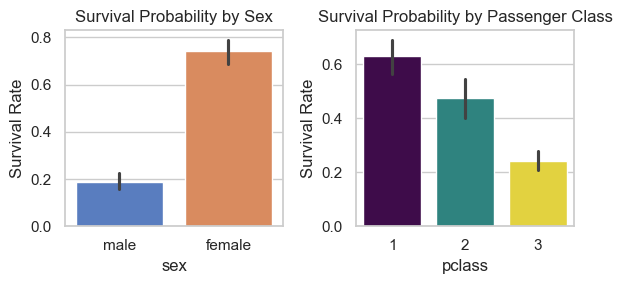

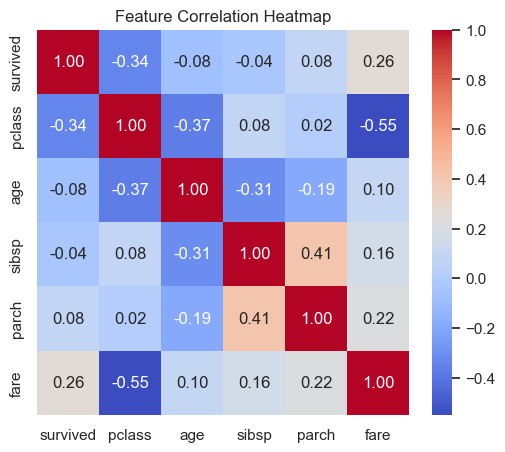

In [245]:
df = sns.load_dataset('titanic')

# Quick Data Inspection
print("--- Dataset Info ---")
print(df.info())
print("\n--- Missing Values ---")
print(df.isnull().sum())

sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(6, 3))

# Survival by Sex
sns.barplot(x='sex', y='survived', data=df, ax=ax[0], palette='muted', hue='sex', legend=False)
ax[0].set_title('Survival Probability by Sex')
ax[0].set_ylabel('Survival Rate')

# Survival by Class
sns.barplot(x='pclass', y='survived', data=df, ax=ax[1], palette='viridis', hue='pclass', legend=False)
ax[1].set_title('Survival Probability by Passenger Class')
ax[1].set_ylabel('Survival Rate')

plt.tight_layout()
plt.show()

# Correlation Heatmap
plt.figure(figsize=(6, 5))
numeric_df = df.select_dtypes(include=['number'])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Heatmap')
plt.show()

## Part 2: Data Cleaning

The titanic dataset contains missing values (N/A) for `Age`. We used the median age to "fill in" for any N/A data, since it is less likely to be skewed by outliers as compared to mean.


We also converted the categorical `sex` and `embarked` features into numerical values. For `sex`, we encoded female as 0, and male as 1. For `embarked`, we encoded S (Southampton) as 0, C (Cherbourg) as 1, Q (Queenstown) as 2.

We also used the presence of missing data within a feature to its advantage, as the `deck` feature has >75% missing values. It can be assumed that the absence of this value is likely due to the fact that this person has a higher likelihood of not surviving since information like what deck they were on would have been harder to obtain. To address this, the survival rate at each cabin was examined, and an encoding system was put in place to emphasize how passengers in certain cabins are more likely to have survived than others.

Finally, we decided to drop column that were redundant or had a large percentage of missing values. The following table describes the features we decided to remove, and the reason why.
| Feature Removed | Redundant To | Reason for Removal |
| :--- | :--- | :--- |
| `alive` | `survived` | Binary indicator of the target variable. Removing prevents data leakage. |
| `who` | `sex` / `age` | Categorizes passengers as man, woman, or child. |
| `embark_town` | `embarked` | Full text name of the embarkation port. |
| `class` | `pclass` | Textual representation of the same thing (First, Second, Third). |
| `alone` | `sibsp` / `parch` | Boolean derived from family size metrics. |

Survival Rate by Deck
  deck      mean  count
0    A  0.466667     15
1    B  0.744681     47
2    C  0.593220     59
3    D  0.757576     33
4    E  0.750000     32
5    F  0.615385     13
6    G  0.500000      4
7    U  0.299419    688


C:\Users\these\AppData\Local\Temp\ipykernel_21820\1527691107.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=survival_stats, x='deck', y='mean', palette='viridis')


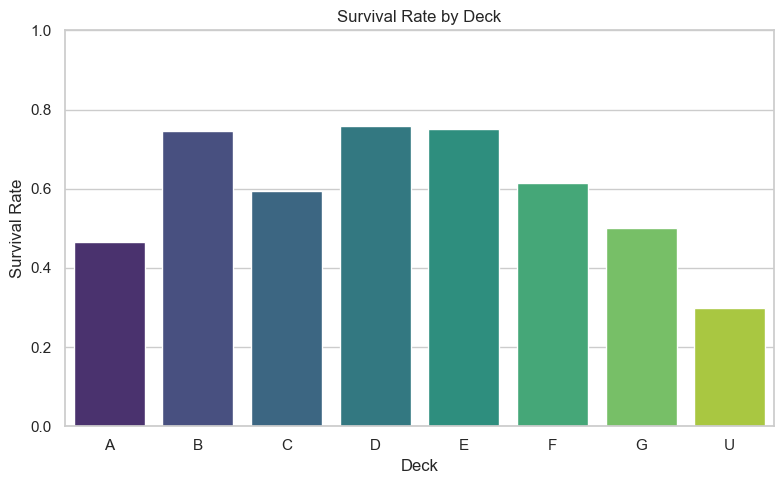

In [246]:
temp = df[['deck', 'survived']]
temp['deck'] = temp['deck'].cat.add_categories('U').fillna('U')

survival_stats = temp.groupby('deck')['survived'].agg(['mean', 'count']).reset_index()

print("Survival Rate by Deck")
print(survival_stats)


plt.figure(figsize=(8, 5))
sns.barplot(data=survival_stats, x='deck', y='mean', palette='viridis')
plt.title('Survival Rate by Deck')
plt.xlabel('Deck')
plt.ylabel('Survival Rate')
plt.ylim(0, 1)
plt.tight_layout()
plt.show()

In [247]:
# Fill missing Age with the Median
df['age'] = df['age'].fillna(df['age'].median())

# Fill missing Embarked with the mode
most_freq_port = df['embarked'].mode()[0]
df['embarked'] = df['embarked'].fillna(most_freq_port)

# Convert Categorical to Numeric
# # female=0, male=1
df['sex'] = df['sex'].map({'female': 0, 'male': 1}).astype(int)

# S=0, C=1, Q=2
df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2}).astype(int)

df['deck'] = df['deck'].cat.add_categories('U').fillna('U')

deck_groups = {
    'B': 3, 'D': 3, 'E': 3,  # High survival
    'C': 2, 'F' : 2,                    # Medium survival
    'A' : 1, 'G': 1,                            # Low survival
    'U': 0                             # Missing / lowest survival
}

df['deck'] = df['deck'].map(deck_groups)


# Drop redundant
drop_cols = ['embark_town', 'alive', 'class', 'who', 'adult_male', 'alone']
df = df.drop(drop_cols, axis=1)

print("--- Cleaning Complete ---")
print(df.head())
print("\nMissing values remaining:", df.isnull().sum().sum())

--- Cleaning Complete ---
   survived  pclass  sex   age  sibsp  parch     fare  embarked  deck
0         0       3    1  22.0      1      0   7.2500         0     0
1         1       1    0  38.0      1      0  71.2833         1     2
2         1       3    0  26.0      0      0   7.9250         0     0
3         1       1    0  35.0      1      0  53.1000         0     2
4         0       3    1  35.0      0      0   8.0500         0     0

Missing values remaining: 0


In [248]:
# Use same train/test split for all models
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Define features (X) and target (y)
X = df.drop('survived', axis=1)
y = df['survived']

# Split the data once so both models use the exact same samples
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Setup complete. Training set shape: {X_train_scaled.shape}")

Setup complete. Training set shape: (712, 8)


## Part 3: Support Vector Machines

After cleaning the dataset, we used SVM to predict whether a passenger survived or not. To study the effect of feature selection, we compared 2 feature sets:
- **Basic** that includes core passenger information: `pclass`, `sex`, `age`, `fare`, and `embarked`.
- **With Family** added `sibsp` and `parch` to include family-related information.


For each feature set, we trained 3 SVM kernels:
- linear
- rbf
- poly

Because SVM is sensitive to feature scale, we standardized the predictors before training using `StandardScaler`. We then computed model accuracy across all combinations of feature set and kernel.

In [249]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
import pandas as pd


feature_sets = {
    "Basic": ['pclass', 'sex', 'age', 'fare', 'embarked'],
    "With Family": ['pclass', 'sex', 'age', 'fare', 'embarked', 'sibsp', 'parch'],
    "Basic + Deck": ['pclass', 'sex', 'age', 'fare', 'embarked', 'deck'],
    "With Family + Deck": ['pclass', 'sex', 'age', 'fare', 'embarked', 'deck', 'sibsp', 'parch'],
}

results = []

for feature_set_name, feature_cols in feature_sets.items():
    X = df[feature_cols]
    y = df['survived']
    
    # Train-test split
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    # Scale features
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    
    # Try multiple SVM kernels
    for kernel in ['linear', 'rbf', 'poly']:
        svm_model = SVC(kernel=kernel)
        svm_model.fit(X_train_scaled, y_train)
        
        y_pred = svm_model.predict(X_test_scaled)
        acc = accuracy_score(y_test, y_pred)
        
        results.append({
            'Feature Set': feature_set_name,
            'Kernel': kernel,
            'Accuracy': acc
        })
        
        print(f"\nFeature Set: {feature_set_name}")
        print(f"Kernel: {kernel}")
        print(f"Accuracy: {acc:.4f}")



Feature Set: Basic
Kernel: linear
Accuracy: 0.7765

Feature Set: Basic
Kernel: rbf
Accuracy: 0.8101

Feature Set: Basic
Kernel: poly
Accuracy: 0.7989

Feature Set: With Family
Kernel: linear
Accuracy: 0.7765

Feature Set: With Family
Kernel: rbf
Accuracy: 0.8156

Feature Set: With Family
Kernel: poly
Accuracy: 0.7989

Feature Set: Basic + Deck
Kernel: linear
Accuracy: 0.7765

Feature Set: Basic + Deck
Kernel: rbf
Accuracy: 0.8101

Feature Set: Basic + Deck
Kernel: poly
Accuracy: 0.8212

Feature Set: With Family + Deck
Kernel: linear
Accuracy: 0.7765

Feature Set: With Family + Deck
Kernel: rbf
Accuracy: 0.8101

Feature Set: With Family + Deck
Kernel: poly
Accuracy: 0.8156


In [250]:
# Display the results in a table
results_df = pd.DataFrame(results).sort_values(by='Accuracy', ascending=False)
print("\n SVM Results")
print(results_df)


 SVM Results
           Feature Set  Kernel  Accuracy
8         Basic + Deck    poly  0.821229
4          With Family     rbf  0.815642
11  With Family + Deck    poly  0.815642
1                Basic     rbf  0.810056
10  With Family + Deck     rbf  0.810056
7         Basic + Deck     rbf  0.810056
2                Basic    poly  0.798883
5          With Family    poly  0.798883
3          With Family  linear  0.776536
0                Basic  linear  0.776536
6         Basic + Deck  linear  0.776536
9   With Family + Deck  linear  0.776536


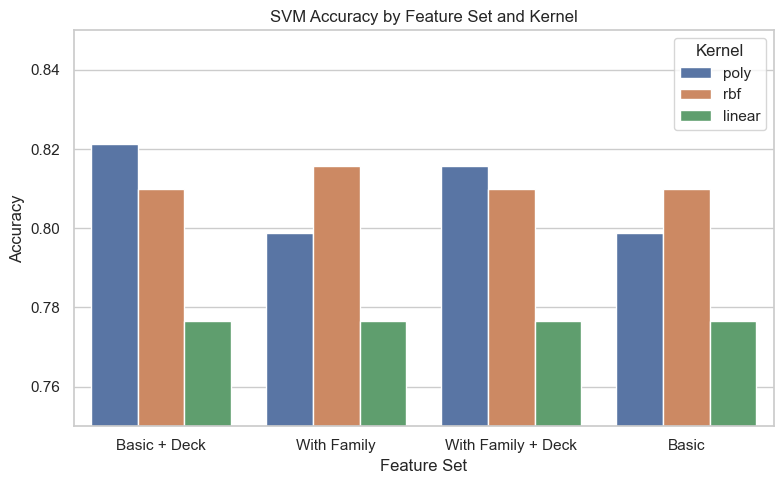

In [251]:
# A bar chat to visualize accuracy by feature set and kernel
plt.figure(figsize=(8, 5))
sns.barplot(data=results_df, x='Feature Set', y='Accuracy', hue='Kernel')
plt.title('SVM Accuracy by Feature Set and Kernel')
plt.ylim(0.75, 0.85)
plt.ylabel('Accuracy')
plt.xlabel('Feature Set')
plt.tight_layout()
plt.show()

Based, on these results, all feature sets that were not the baseline **Basic** peformed better for a specific kernel type. To compare the true performance of these models, the model's optimal kernel type and hyperparameters were tuned.

After comparing the models, the **RBF kernel with the With Family feature set** performed better than the other models. This suggests that the `sibsp` and `parch` added some predictive value.

After selecting the RBF kernel, we tuned its hyperparameters using cross-validation to give a more optimized model in the final SVM setup

In [252]:
from sklearn.model_selection import GridSearchCV

model_scores = []

for feature_set_name in ['Basic + Deck', 'With Family', 'With Family + Deck']:
    X = df[feature_sets[feature_set_name]]
    y = df['survived']
    
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)

    param_grid = {
        'C': [0.1, 1, 10, 100],
        'gamma': [0.001, 0.01, 0.1, 1],
        'kernel': ['poly', 'rbf']
    }

    grid_search = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy', n_jobs=-1)
    grid_search.fit(X_train_scaled, y_train)

    print(f"\nFeature Set: {feature_set_name}")
    print("Best Parameters:", grid_search.best_params_)
    print("Best Cross-Validation Score:", grid_search.best_score_)
    model_scores.append(("SVM: " + feature_set_name, grid_search.best_score_))


Feature Set: Basic + Deck
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8244853737811486

Feature Set: With Family
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8287107258938246

Feature Set: With Family + Deck
Best Parameters: {'C': 10, 'gamma': 0.1, 'kernel': 'rbf'}
Best Cross-Validation Score: 0.8174529695656456


## Part 4: Logistic Regression

In [253]:
# Use the same feature set and train/test split as SVM
from sklearn.model_selection import train_test_split

feature_cols = ['pclass', 'sex', 'age', 'fare', 'embarked', 'deck']

X_lr = df[feature_cols]
y_lr = df['survived']

X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(
    X_lr, y_lr, test_size=0.2, random_state=42, stratify=y_lr
)

# Convert to numpy column vectors to match the custom LR implementation
train_age  = X_train_lr['age']
train_fare = X_train_lr['fare']
train_sex  = X_train_lr['sex']
train_pclass   = X_train_lr['pclass']
train_embarked = X_train_lr['embarked']
train_deck = X_train_lr['deck']

test_age  = X_test_lr['age']
test_fare = X_test_lr['fare']
test_sex  = X_test_lr['sex']
test_pclass   = X_test_lr['pclass']
test_embarked = X_test_lr['embarked']
test_deck = X_test_lr['deck']

train_y = np.reshape(y_train_lr.values, (len(y_train_lr), 1))
test_y  = np.reshape(y_test_lr.values,  (len(y_test_lr),  1))

In [254]:
class LogisticRegression():
    
    def __init__(self, X, y, theta, alpha):
        self.X = X
        self.y = y
        self.theta = theta 
        self.alpha = alpha
    
    #  h (hypothesis): returns p(y=1|x) on inputs contained in the design matrix X
    def sigmoid(self, X): 
        return 1/(1+np.exp(-(X @ self.theta)))
    
    # return predictions of class membership (0,1) of the datapoints in an input matrix X
    def predict(self, X):
        prob = self.sigmoid(X)
        pred = np.zeros(len(prob))
        for i in range(len(prob)):
            if prob[i] >= 0.5: #if greater than 0.5, return 1, else return 0
                pred[i] = 1
            else:
                pred[i] = 0
        return pred
    
    # cost function J()
    def cost(self):
        h_value = self.sigmoid(self.X) #get the hypothesis value
        m = len(h_value)
        cost = self.y.T @ np.log(h_value) + (1-self.y).T @ np.log(1-h_value)
        return np.sum(cost)/(-m)
    
    # update theta 
    def gradient_descent_step(self): 
        h_value = self.sigmoid(self.X) #get the hypothesis value
        diff = h_value - self.y #find the difference between hypothesis value and actual value
        m = len(diff)
        vec = (self.X.T @ diff) / m
        self.theta = self.theta - self.alpha * vec
        return vec
    
    # define a convergence criterion 
    # run gradient descent until convergence 
    def run_gradient_descent(self):
        threshold = 1e-2 #small threshold
        losses = [] #keep track of cost for each step
        loss = self.cost()
        losses.append(loss)
        self.gradient_descent_step()

        norm_grad_vec = 1
        while norm_grad_vec > threshold: #keep running gradient descent until convergence
            grad_vec = self.gradient_descent_step()
            loss = self.cost()
            losses.append(loss)
            norm_grad_vec = np.linalg.norm(grad_vec)
        return losses
    
    # return the model's accuracy on an input (X,y) dataset 
    def evaluate(self, X, y):
        pred = self.predict(X)
        pred = pred.reshape(-1, 1) #need to do this to fit accuracy. Compare column vector to column vector
        accurary = np.mean(pred == y) #compare each of the element and get the mean. (True = 1 and False = 0)
        print("The accurary is ", accurary)
        return accurary
    
    # plot cost function over num gradient descent steps
    def learning_curve(self): 
        #assume that you run_graident_descent first
        plt.figure()
        plt.plot(range(len(losses)), losses)
        plt.title("Cost at each Gradient Descent Step")
        plt.xlabel("Steps")
        plt.ylabel("Cost")
        return losses
    
    # plot decision boundary, based on current model parameters
    def decision_boundary(self):
        X = self.X[:,1:]
        theta = [t[0] for t in self.theta]
        y = np.reshape(self.y, (-1))
        xax = [np.min(X[:, 0]), np.max(X[:, 0])]
        yax = -1.0*(theta[0] + np.dot(theta[1], xax)) / theta[2]
        plt.figure()
        plt.scatter(x=X[y==0,0],y=X[y==0,1],c='red',edgecolor='black')
        plt.scatter(x=X[y==1,0],y=X[y==1,1],c='blue',edgecolor='black')
        plt.plot(xax, yax)
        
        plt.legend(['red','white', 'decision boundary'])
        plt.xlabel('age')  # name it as the your input x- and y-
        plt.ylabel('embarked')
        plt.title('Titanic')        
        plt.show()


In [255]:
#We will want to standardize data to compared features
class standardizeData:
    def findMean(array):
        sum = 0
        for i in array:
            sum += i
        return sum/len(array) #get the mean
    
    def findSigma(array):
        mean = standardizeData.findMean(array)
        sum = 0
        for i in array:
            sum += (i-mean)**2
        return (sum/(len(array)))**0.5 #get the sigma (must square)

    def standardize(array, training): #we only want the means and sigma of training set, so the test set is not influencing anything
        mean = standardizeData.findMean(training)
        sigma = standardizeData.findSigma(training)
        return (array - mean)/sigma #standarize by substracting with means and divide by sigma

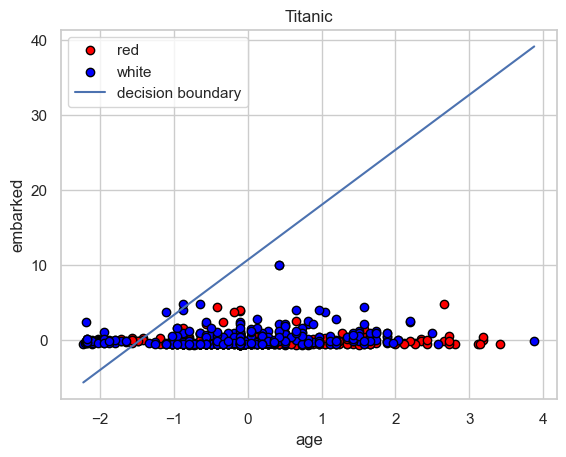

The accurary is  0.770949720670391


In [256]:
# Use all 5 features to match the SVM feature set: pclass, sex, age, fare, embarked
# theta has one entry per feature + one bias term = 6 values
theta = np.array([[0.5], [0.5], [0.5], [0.5], [0.5], [0.5], [0.5]])

train_features = [train_age, train_fare, train_sex, train_pclass, train_embarked, train_deck]
test_features  = [test_age,  test_fare,  test_sex,  test_pclass,  test_embarked, test_deck]

# Standardize using training set statistics only
for i in range(len(train_features)):
    test_features[i]  = standardizeData.standardize(test_features[i],  train_features[i])
    train_features[i] = standardizeData.standardize(train_features[i], train_features[i])

# Build design matrix: bias column + 5 feature columns
design_X = np.zeros((len(train_y), len(theta)))
design_X[:, 0] = 1  # bias term
for i, feat in enumerate(train_features):
    design_X[:, i + 1] = feat.values.reshape(-1)

alpha = 1e-4

model = LogisticRegression(design_X, train_y, theta, alpha)
model.run_gradient_descent()
model.decision_boundary()

# Build test design matrix
test_X = np.zeros((len(test_y), len(theta)))
test_X[:, 0] = 1  # bias term
for i, feat in enumerate(test_features):
    test_X[:, i + 1] = feat.values.reshape(-1)

acc =model.evaluate(test_X, test_y)

model_scores.append(("Logistic Regression: Basic + Deck", acc))

## Summary

C:\Users\these\AppData\Local\Temp\ipykernel_21820\3346130542.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=model_scores_df, x='Model', y='Accuracy', palette='viridis')


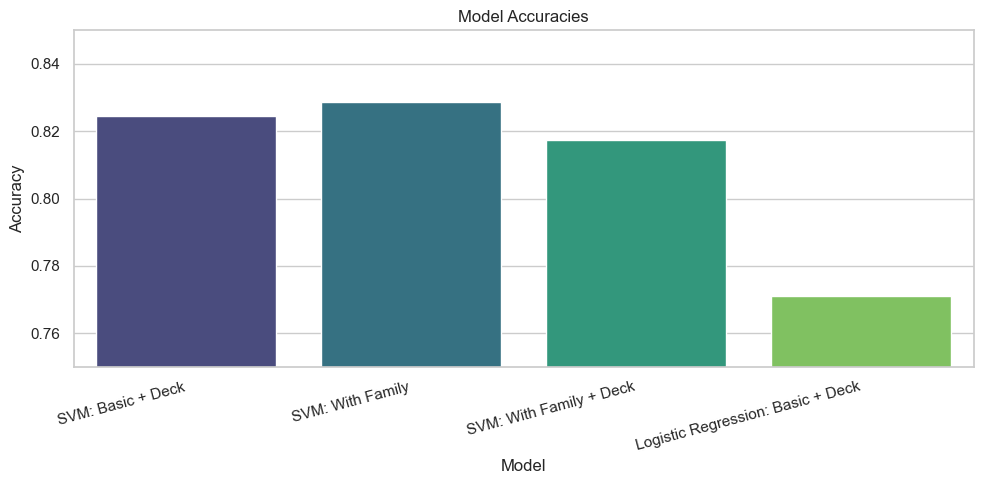

In [257]:
# Plot model accuracies
model_scores_df = pd.DataFrame(model_scores, columns=['Model', 'Accuracy'])

plt.figure(figsize=(10, 5))
sns.barplot(data=model_scores_df, x='Model', y='Accuracy', palette='viridis')
plt.title('Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.ylim(0.75, 0.85)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()